# 03 · Product Recommender

Item-based collaborative filtering with cosine similarity, plus a leave-one-out hit-rate evaluation.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from shopper_spectrum.config import load_config
from shopper_spectrum.data.loader import load_raw
from shopper_spectrum.data.preprocessing import clean
cfg = load_config('../config/config.yaml')
df = clean(load_raw('../data/raw/online_retail.csv'), cfg['preprocessing'])
print('Clean rows:', len(df), '| Customers:', df['CustomerID'].nunique())
df.head()

Clean rows: 392688 | Customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Build customer-product matrix and similarity

In [2]:
from shopper_spectrum.models import recommender as rec
matrix, code2name = rec.build_customer_product_matrix(df, cfg['recommender']['min_customers_per_product'])
sim_df = rec.build_similarity(matrix)
print('Matrix:', matrix.shape, '| Similarity:', sim_df.shape)

Matrix: (4338, 3152) | Similarity: (3152, 3152)


## Get recommendations

In [3]:
neighbors = rec.build_top_neighbors(sim_df, 20)
name2code = rec.build_name_index(code2name, sim_df.index)
for r in rec.recommend('WHITE HANGING HEART T-LIGHT HOLDER', neighbors, code2name, name2code, 5):
    print(f"  {r['product']:<40} {r['score']:.3f}")

  GIN + TONIC DIET METAL SIGN              0.750
  RED HANGING HEART T-LIGHT HOLDER         0.659
  WASHROOM METAL SIGN                      0.644
  LAUNDRY 15C METAL SIGN                   0.642
  GREEN VINTAGE SPOT BEAKER                0.631


## Product similarity heatmap

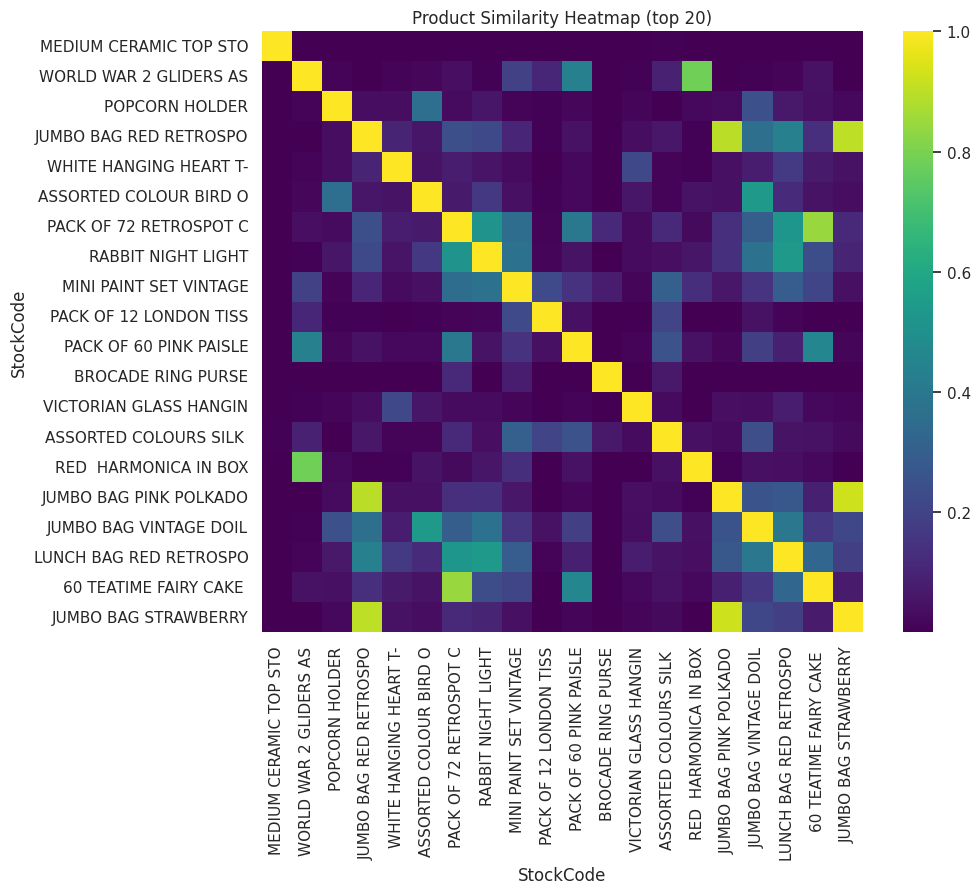

In [4]:
codes = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).index
codes = [c for c in codes if c in sim_df.index][:20]
heat = sim_df.loc[codes, codes]
lbl = [str(code2name.get(c,c))[:22] for c in codes]
plt.figure(figsize=(11,9)); sns.heatmap(heat, xticklabels=lbl, yticklabels=lbl, cmap='viridis', square=True)
plt.title('Product Similarity Heatmap (top 20)'); plt.tight_layout(); plt.show()

## Evaluate: leave-one-out hit rate

In [5]:
hr = rec.evaluate_hit_rate(matrix, neighbors, sample=500, n=5, seed=42)
print(f'Hit-rate@5: {hr:.3f}  (random baseline ~ {5/sim_df.shape[0]:.4f})')

Hit-rate@5: 0.014  (random baseline ~ 0.0016)
